# 04 - Results & Visualization

**Purpose:** Perform a final held-out train/test split that respects `chem_system` grouping (no chemical system appears in both train and test), fit the Random Forest model on the full feature set, report test-set MAE and R^2, and visualize results with a parity plot and a feature importance plot.

**Input:** `../data/bradley_intermetallics_featured.csv`

**Outputs:** `../figures/parity_plot.png`, `../figures/feature_importance.png`

## Final Grouped Train/Test Split

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, r2_score

featured_df = pd.read_csv("../data/bradley_intermetallics_featured.csv")

target_column = "bulk_modulus_vrh"
group_column = "chem_system"
non_feature_columns = {"material_id", "formula", "elements", "crystal_system", "num_elements", target_column, group_column}
feature_columns = [c for c in featured_df.columns if c not in non_feature_columns]

X = featured_df[feature_columns].fillna(0)
y = featured_df[target_column]
chem_system_groups = featured_df[group_column]

# GroupShuffleSplit (not a plain train_test_split) so that every compound from a given chem_system
# ends up entirely in either the train set or the test set, mirroring the GroupKFold approach used
# for cross-validation in 03_modeling and avoiding optimistic leakage across near-duplicate compositions
group_splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(group_splitter.split(X, y, chem_system_groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Unique chem_systems in train: {chem_system_groups.iloc[train_idx].nunique()}, in test: {chem_system_groups.iloc[test_idx].nunique()}")
print(f"Chem systems shared between train and test: {len(set(chem_system_groups.iloc[train_idx]) & set(chem_system_groups.iloc[test_idx]))}")

Train size: 4209, Test size: 1033
Unique chem_systems in train: 2808, in test: 703
Chem systems shared between train and test: 0


## Fit Final Model and Report Test-Set Performance

In [2]:
final_rf_model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
final_rf_model.fit(X_train, y_train)

y_test_pred = final_rf_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Test-set MAE: {test_mae:.2f} GPa")
print(f"Test-set R^2: {test_r2:.3f}")

Test-set MAE: 11.95 GPa
Test-set R^2: 0.847


## Parity Plot (Predicted vs. Actual)

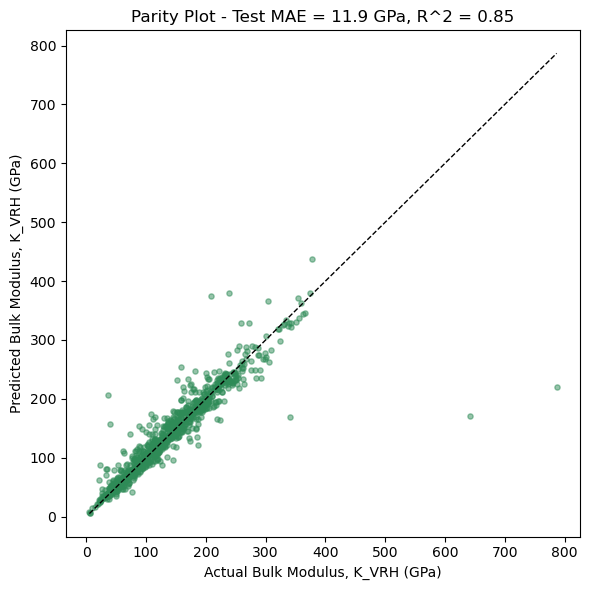

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_test_pred, s=14, alpha=0.5, color="seagreen")

# 1:1 reference line spans the combined range of actual and predicted values
lower_bound = min(y_test.min(), y_test_pred.min())
upper_bound = max(y_test.max(), y_test_pred.max())
ax.plot([lower_bound, upper_bound], [lower_bound, upper_bound], color="black", linestyle="--", linewidth=1)

ax.set_xlabel("Actual Bulk Modulus, K_VRH (GPa)")
ax.set_ylabel("Predicted Bulk Modulus, K_VRH (GPa)")
ax.set_title(f"Parity Plot - Test MAE = {test_mae:.1f} GPa, R^2 = {test_r2:.2f}")
fig.tight_layout()
fig.savefig("../figures/parity_plot.png", dpi=200)
plt.show()

## Feature Importance

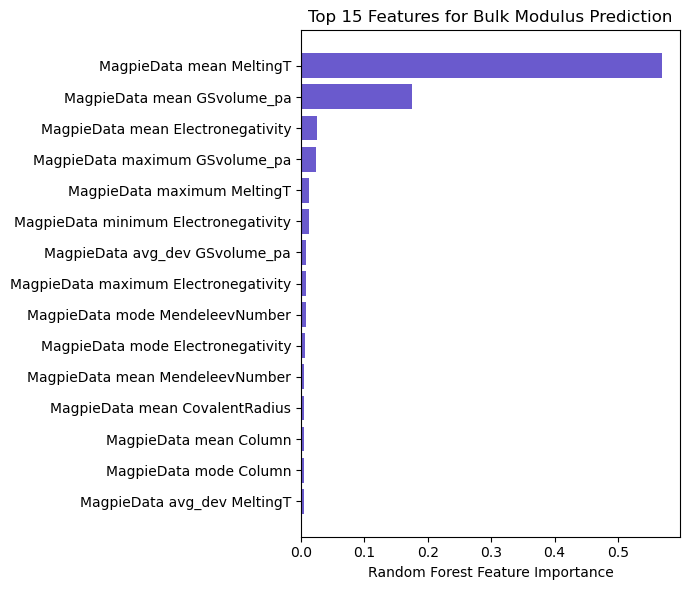

In [4]:
importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": final_rf_model.feature_importances_,
}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="slateblue")
ax.set_xlabel("Random Forest Feature Importance")
ax.set_title("Top 15 Features for Bulk Modulus Prediction")
fig.tight_layout()
fig.savefig("../figures/feature_importance.png", dpi=200)
plt.show()

In [5]:
print("Top 10 feature importances:")
print(importance_df.head(10).to_string(index=False))

residual_analysis_df = pd.DataFrame({
    "crystal_system": featured_df.loc[X_test.index, "crystal_system"],
    "actual": y_test,
    "predicted": y_test_pred,
})
residual_analysis_df["abs_error"] = (residual_analysis_df["actual"] - residual_analysis_df["predicted"]).abs()

crystal_system_error_summary = residual_analysis_df.groupby("crystal_system")["abs_error"].agg(["mean", "count"]).sort_values("mean", ascending=False)

print("\nTest-set MAE by crystal_system (sorted worst to best):")
print(crystal_system_error_summary.to_string())

Top 10 feature importances:
                             feature  importance
            MagpieData mean MeltingT    0.569431
         MagpieData mean GSvolume_pa    0.175349
   MagpieData mean Electronegativity    0.026071
      MagpieData maximum GSvolume_pa    0.024308
         MagpieData maximum MeltingT    0.012805
MagpieData minimum Electronegativity    0.012097
      MagpieData avg_dev GSvolume_pa    0.008143
MagpieData maximum Electronegativity    0.007719
     MagpieData mode MendeleevNumber    0.007230
   MagpieData mode Electronegativity    0.006555

Test-set MAE by crystal_system (sorted worst to best):
                     mean  count
crystal_system                  
trig            30.219767     24
hex_            13.512677    157
tet             11.472423    154
ortho           11.433532    112
cubic           11.006999    570
mono            10.808310     16
